## 📦 Import Libraries

In [1]:
# ===============================
# ENV SETUP (WAJIB PALING ATAS)
# ===============================
import os
# Hindari pencarian CUDA (tidak ada di Mac)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# ===============================
# Data manipulation
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# TensorFlow
# ===============================
import tensorflow as tf

# ===============================
# Transformers (HuggingFace)
# ===============================
from transformers import (
    BertTokenizer,
    TFBertForSequenceClassification,
    create_optimizer
)

# ===============================
# Scikit-learn
# ===============================
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# ===============================
# Utilities
# ===============================
import pickle
import json
import warnings
import platform
warnings.filterwarnings('ignore')

# ===============================
# Reproducibility
# ===============================
np.random.seed(42)
tf.random.set_seed(42)

# ===============================
# System Info
# ===============================
print("🍎 System Info")
print(f"OS      : {platform.system()}")
print(f"Machine : {platform.machine()}")

if platform.system() == "Darwin" and platform.machine() == "arm64":
    print("✅ Apple Silicon detected (M-series)")
    print("🚀 TensorFlow will use Metal backend automatically (if available)")
else:
    print("ℹ️ Non Apple-Silicon environment")

# ===============================
# TensorFlow Info
# ===============================
print("\n✅ Libraries imported successfully!")
print(f"📌 TensorFlow version: {tf.__version__}")

devices = tf.config.list_physical_devices()
print("🔧 Available devices:")
for d in devices:
    print(f"   - {d.device_type}")


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🍎 System Info
OS      : Darwin
Machine : arm64
✅ Apple Silicon detected (M-series)
🚀 TensorFlow will use Metal backend automatically (if available)

✅ Libraries imported successfully!
📌 TensorFlow version: 2.13.0
🔧 Available devices:
   - CPU


## 📁 Load Preprocessed Data

In [2]:
# Load data
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print("📊 Data Loaded:")
print(f"   Training:   {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test:       {len(test_df):,} samples")

📊 Data Loaded:
   Training:   36,861 samples
   Validation: 7,899 samples
   Test:       7,899 samples


In [3]:
# Load label encoder
with open('../models/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Load metadata
with open('../data/processed/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

num_classes = metadata['num_classes']

print(f"\n🏷️ Label Info:")
print(f"   Number of classes: {num_classes}")
print(f"   Classes: {metadata['classes']}")


🏷️ Label Info:
   Number of classes: 7
   Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


In [4]:
# Untuk BERT, gunakan cleaned_text (dengan stopwords)
# BERT dapat memahami konteks dari stopwords
X_train = train_df['cleaned_text'].fillna('').astype(str).values
X_val = val_df['cleaned_text'].fillna('').astype(str).values
X_test = test_df['cleaned_text'].fillna('').astype(str).values

y_train = train_df['label_encoded'].values
y_val = val_df['label_encoded'].values
y_test = test_df['label_encoded'].values

print("✅ Data prepared for BERT training")
print(f"   Train samples with empty text: {sum(len(x.strip()) == 0 for x in X_train)}")
print(f"   Val samples with empty text: {sum(len(x.strip()) == 0 for x in X_val)}")
print(f"   Test samples with empty text: {sum(len(x.strip()) == 0 for x in X_test)}")

✅ Data prepared for BERT training
   Train samples with empty text: 0
   Val samples with empty text: 0
   Test samples with empty text: 0


## 🔤 BERT Tokenization

In [5]:
# Load BERT Tokenizer
print("📥 Loading BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("✅ BERT tokenizer loaded!")

# Hyperparameters
MAX_LEN_BERT = 128  # BERT max sequence length

print(f"\n⚙️ Hyperparameters:")
print(f"   MAX_LEN: {MAX_LEN_BERT}")

📥 Loading BERT tokenizer...
✅ BERT tokenizer loaded!

⚙️ Hyperparameters:
   MAX_LEN: 128


In [6]:
def encode_texts(texts, tokenizer, max_length):
    """
    Encode texts menggunakan BERT tokenizer
    Returns: input_ids dan attention_masks
    """
    input_ids = []
    attention_masks = []
    
    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='tf'
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    
    return tf.concat(input_ids, axis=0), tf.concat(attention_masks, axis=0)

print("✅ Encoding function ready")

✅ Encoding function ready


In [7]:
# Encode datasets
print("🔤 Encoding texts for BERT...")
print("⏰ This may take a few minutes...\n")

print("   Encoding training set...")
X_train_ids, X_train_masks = encode_texts(X_train.tolist(), bert_tokenizer, MAX_LEN_BERT)

print("   Encoding validation set...")
X_val_ids, X_val_masks = encode_texts(X_val.tolist(), bert_tokenizer, MAX_LEN_BERT)

print("   Encoding test set...")
X_test_ids, X_test_masks = encode_texts(X_test.tolist(), bert_tokenizer, MAX_LEN_BERT)

print("\n✅ Encoding complete!")
print(f"   Train IDs shape: {X_train_ids.shape}")
print(f"   Val IDs shape: {X_val_ids.shape}")
print(f"   Test IDs shape: {X_test_ids.shape}")

🔤 Encoding texts for BERT...
⏰ This may take a few minutes...

   Encoding training set...
   Encoding validation set...
   Encoding test set...

✅ Encoding complete!
   Train IDs shape: (36861, 128)
   Val IDs shape: (7899, 128)
   Test IDs shape: (7899, 128)


## 🏗️ Load BERT Model

In [8]:
# Load pretrained BERT
print("📥 Loading BERT model from Hugging Face...")
print("⏰ This may take a few minutes for first time...\n")

# Fix: Use use_safetensors=False to avoid safetensors iteration bug
bert_model = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes,
    use_safetensors=False  # Force loading from h5/pickle format instead of safetensors
)

print("✅ BERT model loaded!")
print(f"   Model: bert-base-uncased")
print(f"   Parameters: ~110M")
print(f"   Output classes: {num_classes}")

📥 Loading BERT model from Hugging Face...
⏰ This may take a few minutes for first time...



TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BERT model loaded!
   Model: bert-base-uncased
   Parameters: ~110M
   Output classes: 7


## ⚙️ Compile Model

In [9]:
# Hyperparameters for training
EPOCHS = 3  # BERT biasanya cukup 3-5 epochs
BATCH_SIZE = 16  # Kurangi jika out of memory
LEARNING_RATE = 2e-5  # Learning rate optimal untuk BERT

# Calculate total training steps
num_train_steps = (len(X_train) // BATCH_SIZE) * EPOCHS
num_warmup_steps = int(0.1 * num_train_steps)  # 10% warmup

print(f"⚙️ Training Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Total Training Steps: {num_train_steps:,}")
print(f"   Warmup Steps: {num_warmup_steps:,}")

⚙️ Training Configuration:
   Epochs: 3
   Batch Size: 16
   Learning Rate: 2e-05
   Total Training Steps: 6,909
   Warmup Steps: 690


In [10]:
# Create optimizer
optimizer, lr_schedule = create_optimizer(
    init_lr=LEARNING_RATE,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps
)

# Compile model
bert_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("✅ Model compiled!")

✅ Model compiled!


## 🏋️ Fine-tuning BERT

In [11]:
# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

print("✅ Callbacks configured")

✅ Callbacks configured


In [12]:
# Training
print("🏋️ Fine-tuning BERT Model...\n")
print("⚠️ WARNING: Training BERT membutuhkan waktu lama!")
print("   ⏰ Estimasi waktu: 1-3 jam (tergantung GPU/CPU)")
print("   💡 Tip: Gunakan Google Colab dengan GPU untuk lebih cepat\n")

history_bert = bert_model.fit(
    {'input_ids': X_train_ids, 'attention_mask': X_train_masks},
    y_train,
    validation_data=(
        {'input_ids': X_val_ids, 'attention_mask': X_val_masks},
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ BERT Fine-tuning Complete!")

🏋️ Fine-tuning BERT Model...

⚠️ WARNING: Training BERT membutuhkan waktu lama!
   ⏰ Estimasi waktu: 1-3 jam (tergantung GPU/CPU)
   💡 Tip: Gunakan Google Colab dengan GPU untuk lebih cepat

Epoch 1/3
2304/2304 [==============================] - 5040s 2s/step - loss: 0.7567 - accuracy: 0.7134 - val_loss: 0.4560 - val_accuracy: 0.8224
Epoch 2/3
2304/2304 [==============================] - 4572s 2s/step - loss: 0.3957 - accuracy: 0.8455 - val_loss: 0.4246 - val_accuracy: 0.8338
Epoch 3/3
2304/2304 [==============================] - 14433s 6s/step - loss: 0.2699 - accuracy: 0.8949 - val_loss: 0.4329 - val_accuracy: 0.8347

✅ BERT Fine-tuning Complete!


## 💾 Save BERT Model

In [13]:
# Save model
print("💾 Saving BERT model...")
bert_model.save_pretrained('../models/bert_model')

print("✅ BERT model saved: models/bert_model/")

💾 Saving BERT model...
✅ BERT model saved: models/bert_model/


## 📊 Visualisasi Training History

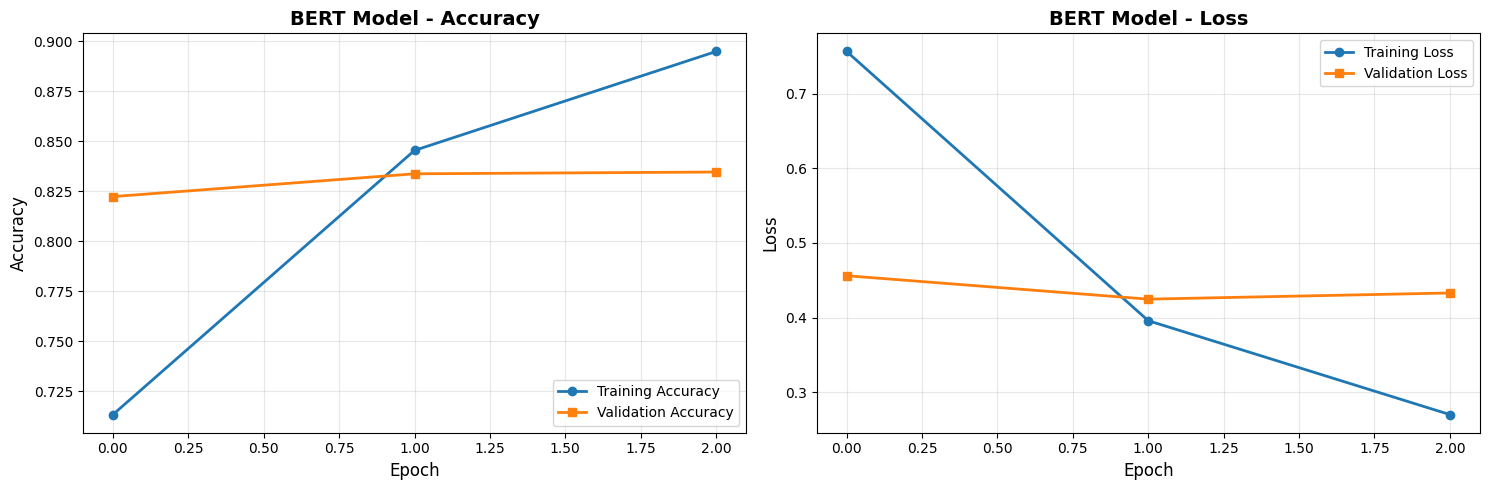

✅ Training history plot saved: results/03_bert_training_history.png


In [14]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_bert.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[0].plot(history_bert.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[0].set_title('BERT Model - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_bert.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[1].plot(history_bert.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[1].set_title('BERT Model - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/03_bert_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plot saved: results/03_bert_training_history.png")

## 🎯 Evaluasi Model pada Test Set

In [15]:
# Predict pada test set
print("🔮 Predicting on test set...")
y_pred_logits = bert_model.predict(
    {'input_ids': X_test_ids, 'attention_mask': X_test_masks},
    verbose=0
)

y_pred = np.argmax(y_pred_logits.logits, axis=1)

print("✅ Prediction complete!")

🔮 Predicting on test set...
✅ Prediction complete!


## 📋 Classification Report

In [16]:
# Classification Report
print("="*80)
print("📋 BERT MODEL - CLASSIFICATION REPORT")
print("="*80)
print()
class_report = classification_report(
    y_test, 
    y_pred, 
    target_names=label_encoder.classes_,
    digits=4
)
print(class_report)

# Save classification report
with open('../results/03_bert_classification_report.txt', 'w') as f:
    f.write(class_report)

print("💾 Classification report saved: results/03_bert_classification_report.txt")

📋 BERT MODEL - CLASSIFICATION REPORT

                      precision    recall  f1-score   support

             Anxiety     0.8208    0.8906    0.8543       576
             Bipolar     0.8492    0.8106    0.8294       417
          Depression     0.7773    0.7544    0.7657      2309
              Normal     0.9562    0.9527    0.9544      2451
Personality disorder     0.6886    0.7143    0.7012       161
              Stress     0.6935    0.7113    0.7023       388
            Suicidal     0.7070    0.7207    0.7138      1597

            accuracy                         0.8191      7899
           macro avg     0.7847    0.7935    0.7887      7899
        weighted avg     0.8196    0.8191    0.8192      7899

💾 Classification report saved: results/03_bert_classification_report.txt


In [17]:
# Calculate accuracy
bert_accuracy = accuracy_score(y_test, y_pred)

print("="*80)
print(f"🎯 BERT MODEL TEST ACCURACY: {bert_accuracy:.4f} ({bert_accuracy*100:.2f}%)")
print("="*80)

🎯 BERT MODEL TEST ACCURACY: 0.8191 (81.91%)


## 🔲 Confusion Matrix

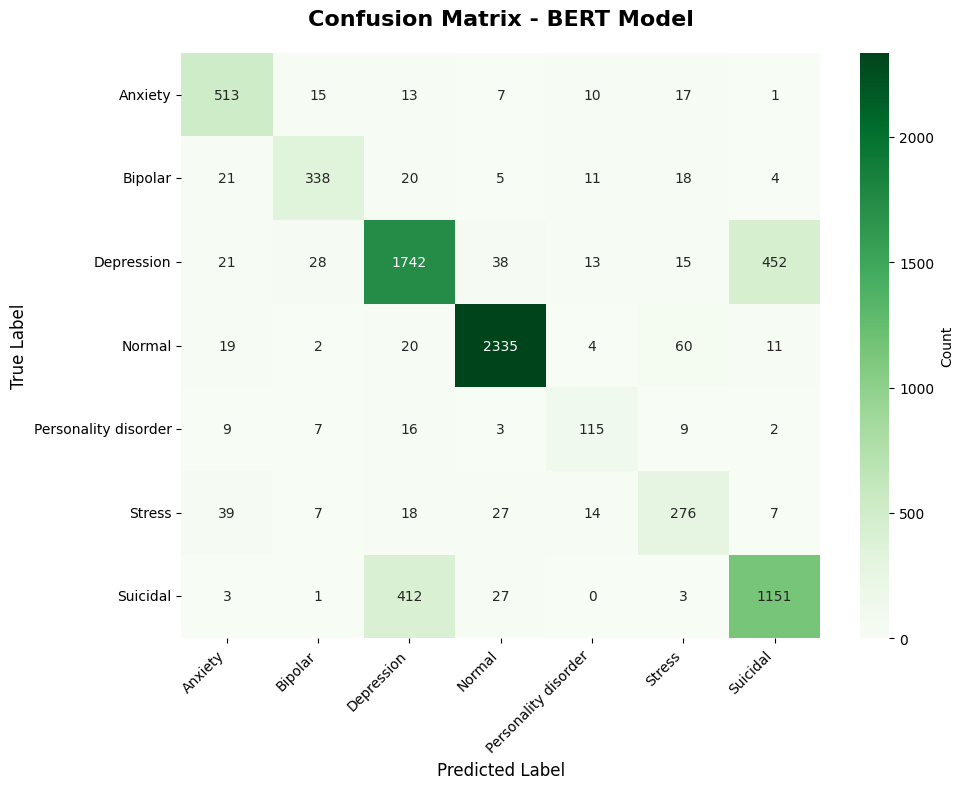

✅ Confusion matrix saved: results/03_bert_confusion_matrix.png


In [18]:
# Confusion Matrix
cm_bert = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_bert, 
    annot=True, 
    fmt='d', 
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - BERT Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/03_bert_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved: results/03_bert_confusion_matrix.png")

## 💾 Simpan Hasil Evaluasi

In [19]:
# Simpan hasil evaluasi
bert_results = {
    'model_name': 'BERT (Pretrained)',
    'accuracy': float(bert_accuracy),
    'test_size': len(y_test),
    'num_classes': num_classes,
    'hyperparameters': {
        'max_len': MAX_LEN_BERT,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'model_name': 'bert-base-uncased'
    },
    'training_history': {
        'epochs_trained': len(history_bert.history['accuracy']),
        'final_train_accuracy': float(history_bert.history['accuracy'][-1]),
        'final_val_accuracy': float(history_bert.history['val_accuracy'][-1]),
        'final_train_loss': float(history_bert.history['loss'][-1]),
        'final_val_loss': float(history_bert.history['val_loss'][-1]),
        'best_val_accuracy': float(max(history_bert.history['val_accuracy'])),
        'best_val_loss': float(min(history_bert.history['val_loss']))
    }
}

# Save to JSON
with open('../results/03_bert_results.json', 'w') as f:
    json.dump(bert_results, f, indent=4)

print("✅ Results saved: results/03_bert_results.json")

✅ Results saved: results/03_bert_results.json


In [20]:
# Simpan history
history_dict = {
    'accuracy': [float(x) for x in history_bert.history['accuracy']],
    'val_accuracy': [float(x) for x in history_bert.history['val_accuracy']],
    'loss': [float(x) for x in history_bert.history['loss']],
    'val_loss': [float(x) for x in history_bert.history['val_loss']]
}

with open('../results/03_bert_history.json', 'w') as f:
    json.dump(history_dict, f, indent=4)

print("✅ Training history saved: results/03_bert_history.json")

✅ Training history saved: results/03_bert_history.json


## 📊 Summary

In [21]:
print("\n" + "="*80)
print("📊 BERT MODEL TRAINING SUMMARY")
print("="*80)

print(f"\n🏗️ Model:")
print(f"   - Type: BERT (Pretrained)")
print(f"   - Base Model: bert-base-uncased")
print(f"   - Parameters: ~110M")
print(f"   - Max Sequence Length: {MAX_LEN_BERT}")

print(f"\n🏋️ Training:")
print(f"   - Epochs Trained: {len(history_bert.history['accuracy'])}")
print(f"   - Batch Size: {BATCH_SIZE}")
print(f"   - Learning Rate: {LEARNING_RATE}")
print(f"   - Final Training Accuracy: {history_bert.history['accuracy'][-1]:.4f}")
print(f"   - Final Validation Accuracy: {history_bert.history['val_accuracy'][-1]:.4f}")

print(f"\n🎯 Test Results:")
print(f"   - Test Accuracy: {bert_accuracy:.4f} ({bert_accuracy*100:.2f}%)")
print(f"   - Test Samples: {len(y_test):,}")

print(f"\n💾 Files Saved:")
print(f"   ✓ models/bert_model/")
print(f"   ✓ results/03_bert_training_history.png")
print(f"   ✓ results/03_bert_confusion_matrix.png")
print(f"   ✓ results/03_bert_classification_report.txt")
print(f"   ✓ results/03_bert_results.json")
print(f"   ✓ results/03_bert_history.json")

print(f"\n🎯 Next Step: 04_distilbert_model.ipynb")
print("="*80)


📊 BERT MODEL TRAINING SUMMARY

🏗️ Model:
   - Type: BERT (Pretrained)
   - Base Model: bert-base-uncased
   - Parameters: ~110M
   - Max Sequence Length: 128

🏋️ Training:
   - Epochs Trained: 3
   - Batch Size: 16
   - Learning Rate: 2e-05
   - Final Training Accuracy: 0.8949
   - Final Validation Accuracy: 0.8347

🎯 Test Results:
   - Test Accuracy: 0.8191 (81.91%)
   - Test Samples: 7,899

💾 Files Saved:
   ✓ models/bert_model/
   ✓ results/03_bert_training_history.png
   ✓ results/03_bert_confusion_matrix.png
   ✓ results/03_bert_classification_report.txt
   ✓ results/03_bert_results.json
   ✓ results/03_bert_history.json

🎯 Next Step: 04_distilbert_model.ipynb
